# Pipeline base para Preprocesamiento de Imágenes Sentinel-2

**Autor:** Joaquin Llarena

**Fecha:** Marzo 2026

---

## Proyecto

Este notebook presenta un flujo estructurado para la carga, selección de bandas, generación de composiciones multiespectrales y recorte espacial de imágenes Sentinel-2.

El código está diseñado como una plantilla reutilizable, permitiendo adaptar fácilmente:
- Las bandas de interés.
- El área de estudio (AOI).
- Los parámetros de visualización y exportación.

Si bien no constituye un proceso totalmente automatizado, proporciona una base organizada y replicable para distintos tipos de análisis con imágenes multiespectrales.

Los productos generados en este notebook constituyen la base para el análisis de severidad presentado en el notebook complementario.

---

## Flujo de trabajo

1. **Carga de datos**  
   Lectura del AOI e identificación de productos Sentinel-2 (.SAFE) pre y post evento.

2. **Extracción de bandas**  
   Selección de bandas RGB (B02, B03, B04) y bandas necesarias para índices espectrales.

3. **Recorte y alineación espacial**  
   Recorte de cada producto al área de estudio, verificación de CRS y reproyección cuando es necesario.

4. **Generación de stacks y mosaico**  
   Construcción de composiciones multibanda y consolidación espacial de escenas.

5. **Exportación**  
   Generación de archivos finales pre y post listos para análisis posteriores.

---

## 1) Configuraciones iniciales

### 1.1 Carga de librerias 

In [22]:
import rasterio
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.io import MemoryFile
from rasterio.merge import merge
import geopandas as gpd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

### 1.2 Funciones auxiliares

In [23]:
# Funcion para extraer el tile del SAFE

def extraer_tile(nombre_safe):
    
    partes = nombre_safe.split("_")
    return next((p for p in partes if p.startswith("T") and len(p) == 6), None)

In [24]:
# Funcion para extraer las bandas de cada SAFE 
# Devuelve los paths de las bandas necesarias: B02, B03, B04 (RGB), B8A, B12 (NBR) y extras para clasificacion.

def extraer_bandas_safe(safe_path):
    
    r20m_path = next(Path(safe_path).glob("GRANULE/*/IMG_DATA/R20m"))

    return {
        "B02": next(r20m_path.glob("*_B02_20m.jp2")),   # Blue
        "B03": next(r20m_path.glob("*_B03_20m.jp2")),   # Green
        "B04": next(r20m_path.glob("*_B04_20m.jp2")),   # Red
        "B8A": next(r20m_path.glob("*_B8A_20m.jp2")),   # NIR narrow
        "B11": next(r20m_path.glob("*_B11_20m.jp2")),   # SWIR1 
        "B12": next(r20m_path.glob("*_B12_20m.jp2")),   # SWIR2 
        "SCL": next(r20m_path.glob("*_SCL_20m.jp2"))    # Scene Classification
    }

In [25]:
# Funcion para obtener el CRS del SAFE

def obtener_crs_safe(safe_path):
    banda = extraer_bandas_safe(safe_path)["B04"]
    with rasterio.open(banda) as src:
        return src.crs

In [26]:
# Funcion que recorta una banda al AOI.

def recortar_banda_aoi(ruta_banda, aoi):
    
    with rasterio.open(ruta_banda) as src:
        aoi_proj = aoi.to_crs(src.crs)  #  El AOI se reproyecta automáticamente al CRS del raster.
        out_image, out_transform = mask(src, aoi_proj.geometry, crop=True)
        
        return out_image[0], out_transform, src.crs

In [27]:
# Funcion para procesar y generar el "archivo final"
# Extrae y recorta bandas RGB + NBR.
# Devuelve stack multibanda + transform + CRS.

def procesar_safe(safe_path, aoi):
    
    bandas = extraer_bandas_safe(safe_path)

    stack_list = []
    transform = None
    crs = None

    for band in ["B02", "B03", "B04", "B8A", "B11", "B12", "SCL"]:
        recorte, transform, crs = recortar_banda_aoi(bandas[band], aoi)
        stack_list.append(recorte)

    stack = np.stack(stack_list)

    return stack, transform, crs

In [28]:
# Reproyecto los stacks que esten en otro CRS

def reproyectar_stacks_a_crs(stacks, crs_destino):
    
    stacks_reproyectados = []
    
    for item in stacks:
        
        stack = item["stack"]
        transform = item["transform"]
        crs_origen = item["crs"]
        
        if crs_origen == crs_destino:
            stacks_reproyectados.append(item)
            continue
        
        height, width = stack.shape[1], stack.shape[2]
        
        new_transform, new_width, new_height = calculate_default_transform(
            crs_origen,
            crs_destino,
            width,
            height,
            *array_bounds(height, width, transform)
        )
        
        stack_reproyectado = np.zeros(
            (stack.shape[0], new_height, new_width),
            dtype=stack.dtype
        )
        
        for i in range(stack.shape[0]):
            reproject(
                source=stack[i],
                destination=stack_reproyectado[i],
                src_transform=transform,
                src_crs=crs_origen,
                dst_transform=new_transform,
                dst_crs=crs_destino,
                resampling=Resampling.bilinear
            )
        
        stacks_reproyectados.append({
            "name": item["name"],
            "stack": stack_reproyectado,
            "transform": new_transform,
            "crs": crs_destino
        })
    
    return stacks_reproyectados

In [29]:
# Mosaicar stacks

def mosaicar_stacks(stacks):
    
    datasets = []
    
    for item in stacks:
        
        stack = item["stack"]
        transform = item["transform"]
        crs = item["crs"]
        
        memfile = MemoryFile()
        
        dataset = memfile.open(
            driver="GTiff",
            height=stack.shape[1],
            width=stack.shape[2],
            count=stack.shape[0],
            dtype=stack.dtype,
            crs=crs,
            transform=transform,
        )
        
        dataset.write(stack)
        datasets.append(dataset)
    
    mosaic, mosaic_transform = merge(datasets)
    
    for ds in datasets:
        ds.close()
    
    return mosaic, mosaic_transform

In [30]:
# Recorte final del mosaico por AOI 
# Evita sectores sin datos por fuera del AOI que se generen por el merge

def recortar_por_aoi(mosaic_array, mosaic_transform, crs, aoi_gdf):
    
    with MemoryFile() as memfile:
        
        with memfile.open(
            driver="GTiff",
            height=mosaic_array.shape[1],
            width=mosaic_array.shape[2],
            count=mosaic_array.shape[0],
            dtype=mosaic_array.dtype,
            crs=crs,
            transform=mosaic_transform,
        ) as dataset:
            
            dataset.write(mosaic_array)
            
            # Reproyectar AOI al CRS del mosaico
            aoi_proj = aoi_gdf.to_crs(crs)
            
            mosaic_recortado, transform_recortado = mask(
                dataset,
                aoi_proj.geometry,
                crop=True
            )
    
    return mosaic_recortado, transform_recortado

### 1.3 Rutas

In [31]:
# Raíz del proyecto (sube un nivel desde Notebooks)
BASE_DIR = Path("../")

# Rutas principales
DATA_DIR = BASE_DIR / "Data"
RAW_DIR = DATA_DIR / "Raw"
PROCESSED_DIR = DATA_DIR / "Processed"
AOI_DIR = DATA_DIR / "aoi"

# Subcarpetas
RAW_PRE = RAW_DIR / "Pre"
RAW_POST = RAW_DIR / "Post"

PROCESSED_PRE = PROCESSED_DIR / "Pre"
PROCESSED_POST = PROCESSED_DIR / "Post"

In [32]:
# Creo los directorios para las imagenes procesadas

PROCESSED_PRE.mkdir(parents=True, exist_ok=True)
PROCESSED_POST.mkdir(parents=True, exist_ok=True)

## 2) Carga y verificacion de datos

### 2.1 AOI

In [33]:
AOI_PATH = AOI_DIR / "study_area.gpkg"

aoi = gpd.read_file(AOI_PATH)

In [34]:
aoi.head()

,id,geometry
0,NaN,"MULTIPOLYGON (((741446.195 5225775.306, 741446..."


In [35]:
print("CRS del AOI:", aoi.crs)

CRS del AOI: EPSG:32718


### 2.2 Listado de imagenes

In [36]:
pre_safe = sorted(RAW_PRE.glob("*.SAFE"))
post_safe = sorted(RAW_POST.glob("*.SAFE"))

print("Imágenes PRE encontradas:")
for s in pre_safe:
    tile = extraer_tile(s.name)
    crs = obtener_crs_safe(s)
    print(f"- {s.name} | Tile: {tile} | CRS: {crs}")

print("\nImágenes POST encontradas:")
for s in post_safe:
    tile = extraer_tile(s.name)
    crs = obtener_crs_safe(s)
    print(f"- {s.name} | Tile: {tile} | CRS: {crs}")

print(f"\nTotal PRE: {len(pre_safe)}")
print(f"Total POST: {len(post_safe)}")

Imágenes PRE encontradas:
- S2B_MSIL2A_20251125T142709_N0511_R053_T18GYT_20251125T180610.SAFE | Tile: T18GYT | CRS: EPSG:32718
- S2B_MSIL2A_20251125T142709_N0511_R053_T18GYU_20251125T180610.SAFE | Tile: T18GYU | CRS: EPSG:32718
- S2B_MSIL2A_20251125T142709_N0511_R053_T19GCN_20251125T180610.SAFE | Tile: T19GCN | CRS: EPSG:32719
- S2B_MSIL2A_20251125T142709_N0511_R053_T19GCP_20251125T180610.SAFE | Tile: T19GCP | CRS: EPSG:32719

Imágenes POST encontradas:
- S2C_MSIL2A_20260218T142711_N0512_R053_T18GYT_20260218T174410.SAFE | Tile: T18GYT | CRS: EPSG:32718
- S2C_MSIL2A_20260218T142711_N0512_R053_T18GYU_20260218T174410.SAFE | Tile: T18GYU | CRS: EPSG:32718
- S2C_MSIL2A_20260218T142711_N0512_R053_T19GCN_20260218T174410.SAFE | Tile: T19GCN | CRS: EPSG:32719
- S2C_MSIL2A_20260218T142711_N0512_R053_T19GCP_20260218T174410.SAFE | Tile: T19GCP | CRS: EPSG:32719

Total PRE: 4
Total POST: 4


## 3) Procesamiento

Procesamiento de datos, explicar

## Pre

In [37]:
# Creo los stacks PRE
stacks_pre = []

for safe in pre_safe:
    stack, transform, crs = procesar_safe(safe, aoi)
    
    stacks_pre.append({
        "name": safe.name,
        "stack": stack,
        "transform": transform,
        "crs": crs
    })

In [38]:
# Chequedo los datos
for item in stacks_pre:
    print(item["name"], item["stack"].shape, item["crs"])

S2B_MSIL2A_20251125T142709_N0511_R053_T18GYT_20251125T180610.SAFE (7, 3713, 3416) EPSG:32718
S2B_MSIL2A_20251125T142709_N0511_R053_T18GYU_20251125T180610.SAFE (7, 3095, 3416) EPSG:32718
S2B_MSIL2A_20251125T142709_N0511_R053_T19GCN_20251125T180610.SAFE (7, 3723, 1934) EPSG:32719
S2B_MSIL2A_20251125T142709_N0511_R053_T19GCP_20251125T180610.SAFE (7, 3370, 1934) EPSG:32719


In [39]:
# Reproyecto los stacks todos a un mismo CRS

crs_final = aoi.crs

stacks_pre = reproyectar_stacks_a_crs(stacks_pre, crs_final)

for item in stacks_pre:
    print(item["name"], item["crs"])

S2B_MSIL2A_20251125T142709_N0511_R053_T18GYT_20251125T180610.SAFE EPSG:32718
S2B_MSIL2A_20251125T142709_N0511_R053_T18GYU_20251125T180610.SAFE EPSG:32718
S2B_MSIL2A_20251125T142709_N0511_R053_T19GCN_20251125T180610.SAFE EPSG:32718
S2B_MSIL2A_20251125T142709_N0511_R053_T19GCP_20251125T180610.SAFE EPSG:32718


In [40]:
# Merge
mosaic_pre, mosaic_transform_pre = mosaicar_stacks(stacks_pre)

# Recorte por AOI
mosaic_pre_recortado, transform_pre = recortar_por_aoi(
    mosaic_pre,
    mosaic_transform_pre,
    crs_final,
    aoi
)

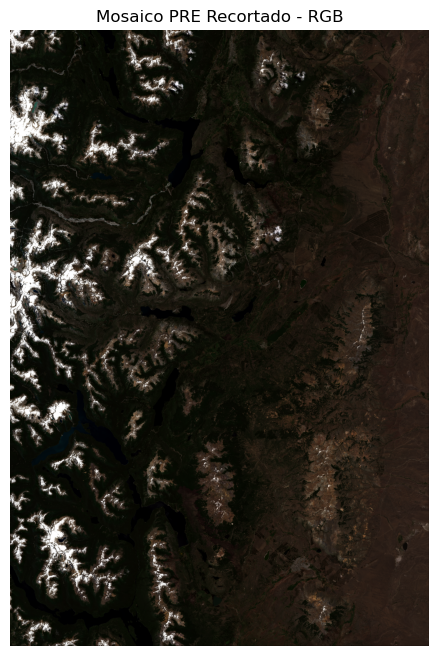

In [41]:
# Extraer bandas (asumiendo B2, B3, B4 en 0,1,2)
red = mosaic_pre_recortado[2]
green = mosaic_pre_recortado[1]
blue = mosaic_pre_recortado[0]

# Stretch robusto
def stretch(band):
    band = band.astype("float32")
    p2 = np.percentile(band, 2)
    p98 = np.percentile(band, 98)
    return np.clip((band - p2) / (p98 - p2), 0, 1)

rgb = np.dstack([
    stretch(red),
    stretch(green),
    stretch(blue)
])

# Calcular extensión espacial real
height, width = red.shape
left, bottom, right, top = array_bounds(height, width, transform_pre)

plt.figure(figsize=(8,8))
plt.imshow(rgb, extent=(left, right, bottom, top))
plt.axis("off")
plt.title("Mosaico PRE Recortado - RGB")
plt.show()

In [42]:
# Definir nombre del archivo
output_path = PROCESSED_PRE / "Sentinel2_20251125_Pre_Mosaic_20m.tif"

with rasterio.open(
    output_path,
    "w",
    driver="GTiff",
    height=mosaic_pre_recortado.shape[1],
    width=mosaic_pre_recortado.shape[2],
    count=mosaic_pre_recortado.shape[0],
    dtype=mosaic_pre_recortado.dtype,
    crs=crs_final,
    transform=transform_pre,
) as dst:
    
    dst.write(mosaic_pre_recortado)

print(f"Mosaico PRE guardado en: {output_path}")

Mosaico PRE guardado en: ..\Data\Processed\Pre\Sentinel2_20251125_Pre_Mosaic_20m.tif


## POST

In [43]:
# Creo los stacks POST
stacks_post = []

for safe in post_safe:
    stack, transform, crs = procesar_safe(safe, aoi)
    
    stacks_post.append({
        "name": safe.name,
        "stack": stack,
        "transform": transform,
        "crs": crs
    })

In [44]:
# Chequeo los datos
for item in stacks_post:
    print(item["name"], item["stack"].shape, item["crs"])

S2C_MSIL2A_20260218T142711_N0512_R053_T18GYT_20260218T174410.SAFE (7, 3713, 3416) EPSG:32718
S2C_MSIL2A_20260218T142711_N0512_R053_T18GYU_20260218T174410.SAFE (7, 3095, 3416) EPSG:32718
S2C_MSIL2A_20260218T142711_N0512_R053_T19GCN_20260218T174410.SAFE (7, 3723, 1934) EPSG:32719
S2C_MSIL2A_20260218T142711_N0512_R053_T19GCP_20260218T174410.SAFE (7, 3370, 1934) EPSG:32719


In [45]:
# Reproyecto los stacks todos a un mismo CRS

crs_final = aoi.crs

stacks_post = reproyectar_stacks_a_crs(stacks_post, crs_final)

for item in stacks_post:
    print(item["name"], item["crs"])

S2C_MSIL2A_20260218T142711_N0512_R053_T18GYT_20260218T174410.SAFE EPSG:32718
S2C_MSIL2A_20260218T142711_N0512_R053_T18GYU_20260218T174410.SAFE EPSG:32718
S2C_MSIL2A_20260218T142711_N0512_R053_T19GCN_20260218T174410.SAFE EPSG:32718
S2C_MSIL2A_20260218T142711_N0512_R053_T19GCP_20260218T174410.SAFE EPSG:32718


In [46]:
# Merge
mosaic_post, mosaic_transform_post = mosaicar_stacks(stacks_post)

# Recorte por AOI
mosaic_post_recortado, transform_post = recortar_por_aoi(
    mosaic_post,
    mosaic_transform_post,
    crs_final,
    aoi
)

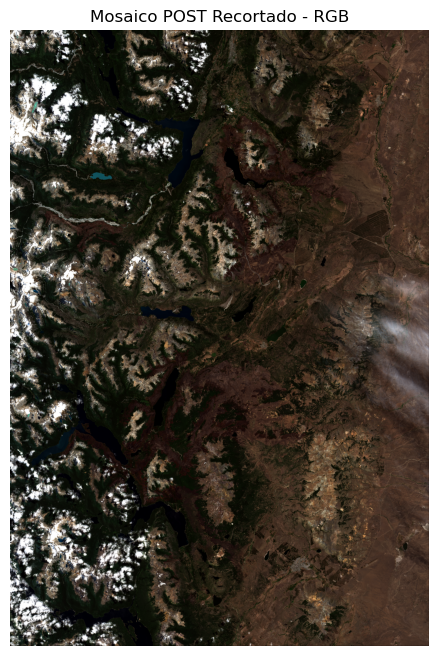

In [47]:
# Extraer bandas (asumiendo B2, B3, B4 en 0,1,2)
red = mosaic_post_recortado[2]
green = mosaic_post_recortado[1]
blue = mosaic_post_recortado[0]

# Stretch robusto
def stretch(band):
    band = band.astype("float32")
    p2 = np.percentile(band, 2)
    p98 = np.percentile(band, 98)
    return np.clip((band - p2) / (p98 - p2), 0, 1)

rgb = np.dstack([
    stretch(red),
    stretch(green),
    stretch(blue)
])

# Calcular extensión espacial real
height, width = red.shape
left, bottom, right, top = array_bounds(height, width, transform_post)

plt.figure(figsize=(8,8))
plt.imshow(rgb, extent=(left, right, bottom, top))
plt.axis("off")
plt.title("Mosaico POST Recortado - RGB")
plt.show()

In [48]:
# Definir nombre del archivo
output_path = PROCESSED_POST / "Sentinel2_20260218_Post_Mosaic_20m.tif"

with rasterio.open(
    output_path,
    "w",
    driver="GTiff",
    height=mosaic_post_recortado.shape[1],
    width=mosaic_post_recortado.shape[2],
    count=mosaic_post_recortado.shape[0],
    dtype=mosaic_post_recortado.dtype,
    crs=crs_final,
    transform=transform_pre,
) as dst:
    
    dst.write(mosaic_post_recortado)

print(f"Mosaico PRE guardado en: {output_path}")

Mosaico PRE guardado en: ..\Data\Processed\Post\Sentinel2_20260218_Post_Mosaic_20m.tif


Los rásters pre y post incendio, ya recortados, alineados y listos para el análisis, fueron almacenados en `data/processed/pre/` y `data/processed/post/`, quedando preparados para el cálculo de índices espectrales y el análisis de severidad.